# Horn bench results

Tables and figures for the 21-model Horn-rule deduction run. All logic lives in `analysis/horn_results.py`; this notebook calls it and shows the outputs inline.

## Load and dedupe every source

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd() / "analysis"))
import horn_results as hr

res = hr.run_pipeline()
counts = pd.DataFrame(
    [
        {"family": fam, "model": m, "m": res.chosen.get(m), **{a: res.summary[m]["arms"][a]["n"] for a in hr.ARMS}, "n": res.summary[m]["n"]}
        if m in res.summary
        else {"family": fam, "model": m, "m": None, **{a: 0 for a in hr.ARMS}, "n": 0}
        for fam, models in hr.FAMILIES
        for m in models
    ]
)
print("\n".join(f"- {a}" for a in res.anomalies))
counts

- spot: skipped snapshot copy exaone-4.5-33b_m16.stopped_0855.jsonl
- spot: skipped snapshot copy glm-4.5-air_m24.stopped_0855.jsonl
- spot: skipped snapshot copy k-exaone-236b-a23b_m32.stopped_0855.jsonl
- b200: skipped snapshot copy qwen3.5-397b-a17b_m64.merged_dedup.jsonl
- gemma-4-31b: spot holds a full run at m=64; pinned to it, dropped 0 rows from other sources
- read 30 files, kept 19559 cells
- ministral-3-14b: dropped 180 rows of retired arms ['junk']
- ministral-3-3b: dropped 90 rows of retired arms ['junk']
- ministral-3-8b: dropped 90 rows of retired arms ['junk']
- exaone-4.0-32b: dropped model, 52 rows ignored
- exaone-4.5-33b: dropped model, 433 rows ignored
- glm-4.5-air: dropped model, 313 rows ignored
- k-exaone-236b-a23b: dropped model, 216 rows ignored
- nemotron-3-nano-4b: dropped 754 rows from orcd; only spot counts for this model
- deepseek-v3.1: 29 duplicate cells within one source (kept the non-exception or first)
- gemma-4-31b: 1184 duplicate cells within one 

,family,model,m,lem,pad,disc,both,n
0,Gemma 4,gemma-4-e2b,6,300,300,300,300,1200
1,Gemma 4,gemma-4-12b,32,300,300,300,300,1200
2,Gemma 4,gemma-4-31b,64,300,300,300,300,1200
3,Nemotron 3,nemotron-3-nano-4b,2,300,300,300,300,1200
4,Nemotron 3,nemotron-3-nano-30b-a3b,6,300,300,300,300,1200
5,Nemotron 3,nemotron-3-super-120b-a12b,20,300,300,300,300,1200
6,Qwen3.5,qwen3.5-27b,64,300,300,300,300,1200
7,Qwen3.5,qwen3.5-122b-a10b,48,300,300,300,300,1200
8,Qwen3.5,qwen3.5-397b-a17b,64,300,300,300,300,1200
9,DeepSeek,deepseek-v4-flash,64,300,300,300,300,1200


## Results table

Pass rate = mean over seeds of per-seed pass@1; ± = 95% CI half-width over seeds. Bold = best arm, italic = worst. Deltas in points, seed-paired, with 95% CI; stars from the sign-flip p, † survives Holm across models.

In [2]:
def _pm(st):
    return "—" if st["mean"] is None else f"{st['mean']:.3f} ± {(st['hi'] - st['lo']) / 2:.3f} ({st['n']})"


def _delta(d):
    if d["n_seeds"] == 0:
        return "—"
    return f"{d['mean']:+.1f}{hr.stars(d['p'])}{'†' if d.get('holm') else ''} [{d['lo']:+.1f}, {d['hi']:+.1f}]"


rows, marks = [], {}
for fam, models in hr.FAMILIES:
    for m in models:
        s = res.summary.get(m)
        name = hr.DISPLAY[m] + (f" ^{hr.flags(s)}" if s and hr.flags(s) else "")
        if s is None:
            rows.append({"family": fam, "model": name, "m": "", "n": 0, **{a: "—" for a in hr.ARMS}, **{f"{a} − {b}": "—" for a, b in hr.DELTAS}})
            continue
        rows.append({"family": fam, "model": name, "m": s["m"], "n": s["n"], **{a: _pm(s["arms"][a]) for a in hr.ARMS},
                     **{f"{a} − {b}": _delta(s["deltas"][f"{a}-{b}"]) for a, b in hr.DELTAS}})
        marks[len(rows) - 1] = hr.best_worst(s["arms"])

table = pd.DataFrame(rows)


def _style(row):
    best, worst = marks.get(row.name, (None, None))
    return ["font-weight: bold" if c == best else "font-style: italic" if c == worst else "" for c in table.columns]


table.style.apply(_style, axis=1).hide(axis="index")

family,model,m,n,lem,pad,disc,both,lem − both,pad − both,disc − both
Gemma 4,E2B,6,1200,0.913 ± 0.035 (300),0.783 ± 0.053 (300),0.607 ± 0.065 (300),0.457 ± 0.067 (300),"+45.7***† [+38.0, +53.0]","+32.7***† [+24.3, +40.7]","+15.0***† [+7.7, +22.3]"
Gemma 4,12B,32,1200,0.760 ± 0.058 (300),0.533 ± 0.060 (300),0.310 ± 0.060 (300),0.237 ± 0.050 (300),"+52.3***† [+44.3, +59.3]","+29.7***† [+22.0, +37.3]","+7.3 [-0.3, +15.0]"
Gemma 4,31B,64,1200,0.657 ± 0.060 (300),0.587 ± 0.062 (300),0.260 ± 0.057 (300),0.140 ± 0.040 (300),"+51.7***† [+44.3, +58.7]","+44.7***† [+37.3, +52.0]","+12.0**† [+5.3, +19.0]"
Nemotron 3,Nano-4B,2,1200,0.813 ± 0.052 (300),0.670 ± 0.065 (300),0.727 ± 0.058 (300),0.550 ± 0.067 (300),"+26.3***† [+19.3, +33.3]","+12.0**† [+4.0, +20.0]","+17.7***† [+10.0, +25.3]"
Nemotron 3,Nano-30B-A3B ^d,6,1200,0.657 ± 0.055 (300),0.287 ± 0.058 (300),0.053 ± 0.025 (300),0.043 ± 0.025 (300),"+61.3***† [+55.7, +67.0]","+24.3***† [+18.7, +30.3]","+1.0 [-2.3, +4.3]"
Nemotron 3,Super-120B-A12B,20,1200,0.643 ± 0.065 (300),0.477 ± 0.058 (300),0.103 ± 0.035 (300),0.080 ± 0.032 (300),"+56.3***† [+49.0, +63.7]","+39.7***† [+33.0, +46.7]","+2.3 [-3.0, +7.7]"
Qwen3.5,27B,64,1200,0.697 ± 0.053 (300),0.667 ± 0.062 (300),0.503 ± 0.067 (300),0.137 ± 0.045 (300),"+56.0***† [+48.7, +63.0]","+53.0***† [+45.3, +60.3]","+36.7***† [+29.3, +44.3]"
Qwen3.5,122B-A10B,48,1200,0.690 ± 0.055 (300),0.630 ± 0.063 (300),0.590 ± 0.055 (300),0.247 ± 0.055 (300),"+44.3***† [+37.0, +51.7]","+38.3***† [+31.0, +45.7]","+34.3***† [+26.7, +42.0]"
Qwen3.5,397B-A17B ^b,64,1200,0.683 ± 0.058 (300),0.643 ± 0.062 (300),0.673 ± 0.060 (300),0.417 ± 0.063 (300),"+26.7***† [+18.3, +34.7]","+22.7***† [+14.3, +31.3]","+25.7***† [+16.7, +34.7]"
DeepSeek,V4-Flash,64,1200,0.730 ± 0.053 (300),0.850 ± 0.047 (300),0.653 ± 0.053 (300),0.407 ± 0.055 (300),"+32.3***† [+24.7, +40.0]","+44.3***† [+38.0, +50.7]","+24.7***† [+17.3, +32.0]"


## Arm pass rates along each family ladder

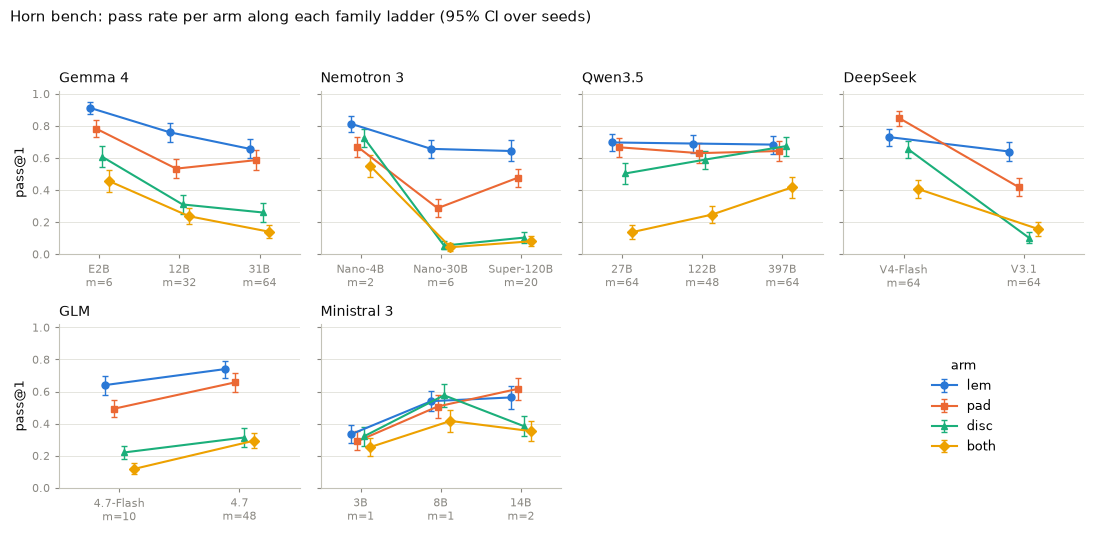

In [3]:
hr.figure_arms(res.summary);

## Deltas along each family ladder

Band = seed-paired 95% CI. Points with fewer than 10 seeds are left off.

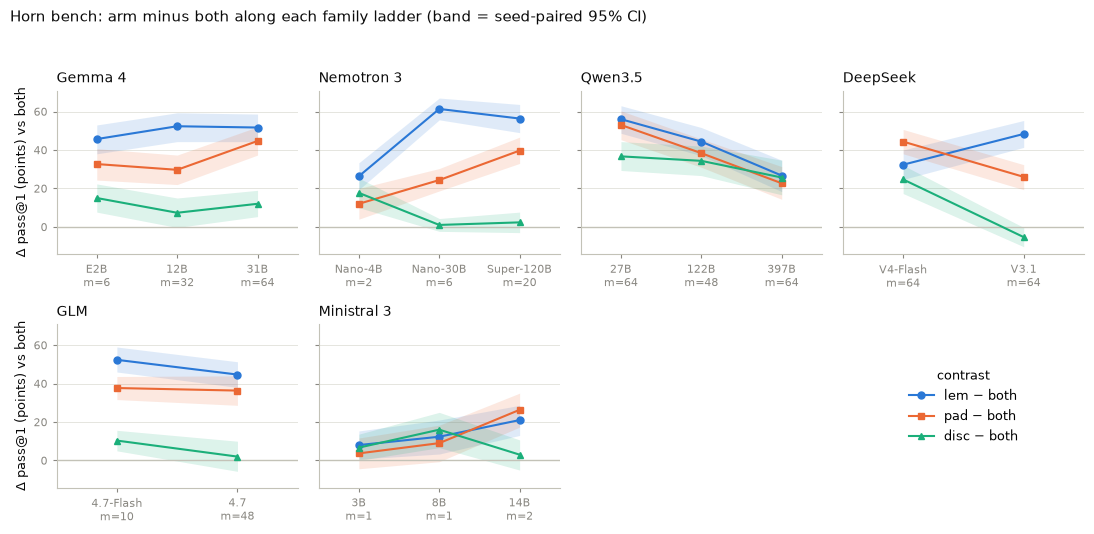

In [4]:
hr.figure_deltas(res.summary);

## Diagnostics per arm

Verdict counts, output-cap hits and mean token counts, to separate cap hits from wrong proofs.

In [5]:
diag = pd.DataFrame(
    [{"model": m, "arm": a, **d} for m, per_arm in res.diag.items() for a, d in per_arm.items() if d["n"]]
).rename(columns={"mean_completion_tokens": "mean out tok", "mean_prompt_tokens": "mean in tok"})
diag.style.format({"mean out tok": "{:,.0f}", "mean in tok": "{:,.0f}"}).hide(axis="index")

model,arm,n,success,length,invalid_step,incomplete,given_up,no_answer,missing,finish_length,mean out tok,mean in tok
gemma-4-e2b,lem,300,274,0,26,0,0,0,0,0,"2,243",801
gemma-4-e2b,pad,300,235,0,65,0,0,0,0,0,"2,596","1,963"
gemma-4-e2b,disc,300,182,1,111,4,0,2,0,1,"3,717","2,508"
gemma-4-e2b,both,300,137,0,161,2,0,0,0,0,"4,398","2,507"
gemma-4-12b,lem,300,228,19,53,0,0,0,0,19,"26,787","3,478"
gemma-4-12b,pad,300,160,52,88,0,0,0,0,52,"36,038","9,656"
gemma-4-12b,disc,300,93,163,44,0,0,0,0,163,"70,944","12,589"
gemma-4-12b,both,300,71,150,79,0,0,0,0,150,"68,392","12,586"
gemma-4-31b,lem,300,197,3,100,0,0,0,0,3,"13,973","6,773"
gemma-4-31b,pad,300,176,4,120,0,0,0,0,4,"13,531","19,140"


## Write the outputs

Same files as the CLI: `results/horn_table.tex`, `horn_table.md`, `horn_diagnostics.md`, `horn_summary.json` and the two figures as PDF and PNG.

In [6]:
import matplotlib.pyplot as plt

written = hr.write_outputs(res, hr.OUT)
plt.close("all")
print("\n".join(str(p.relative_to(hr.REPO)) for p in written))

notebooks/deduction/results/horn_table.md
notebooks/deduction/results/horn_diagnostics.md
notebooks/deduction/results/horn_table.tex
notebooks/deduction/results/horn_table_full.tex
notebooks/deduction/results/horn_summary.json
notebooks/deduction/results/horn_ladder_arms.pdf
notebooks/deduction/results/horn_ladder_arms.png
notebooks/deduction/results/horn_ladder_deltas.pdf
notebooks/deduction/results/horn_ladder_deltas.png
